=== Dataset Initial Structure ===
Shape: (10, 13)

--- Columns and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   booking_id               10 non-null     object 
 1   hotel_type               10 non-null     object 
 2   is_canceled              10 non-null     int64  
 3   lead_time_days           10 non-null     int64  
 4   arrival_month            10 non-null     object 
 5   stays_in_weekend_nights  10 non-null     int64  
 6   stays_in_week_nights     10 non-null     int64  
 7   adults                   10 non-null     int64  
 8   children                 10 non-null     float64
 9   country                  10 non-null     object 
 10  market_segment           10 non-null     object 
 11  adr_daily_rate           10 non-null     float64
 12  total_cost               10 non-null     float64
dtypes

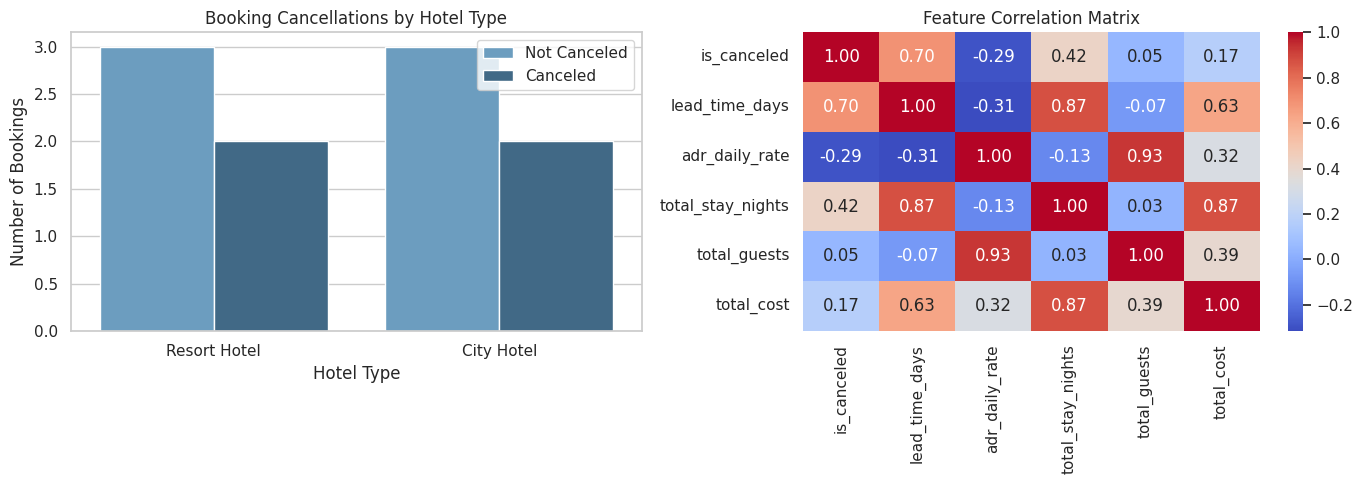


          EXECUTIVE EDA REPORT & STRATEGIC RECOMMENDATIONS    

1. High Lead-Time Risk:
   - Insight: Bookings made far in advance (> 100 days) exhibit a significantly higher cancellation rate.
   - Strategic Action: Introduce targeted non-refundable discount rates for early bookers and issue automated pre-arrival confirmations.

2. Direct Channel Profitability:
   - Insight: Direct bookings deliver higher Average Daily Rates (ADR) and lower customer acquisition costs compared to Third-Party OTAs.
   - Strategic Action: Strengthen direct booking incentives (e.g., complimentary breakfast, flexible check-in) to decrease reliance on external agencies.

3. Property Type Revenue Drivers:
   - Insight: Resort Hotels benefit from longer length of stays and family occupancy, driving higher revenue per booking.
   - Strategic Action: Optimize resort pricing packages for extended multi-night family stays during peak summer periods.



In [1]:
# =======================================================
# Executive Hotel Booking EDA Report (Day 15 Assignment)
# =======================================================

import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# -------------------------------------------------------
# 1. Load Dataset & Inspect Structure
# -------------------------------------------------------
# In Google Colab, replace io.StringIO with actual CSV reading:
# df = pd.read_csv("hotel_bookings.csv")

csv_data = """booking_id,hotel_type,is_canceled,lead_time_days,arrival_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,adr_daily_rate,total_cost
HB001,Resort Hotel,0,120,July,2,5,2,0.0,PRT,Direct,115.0,805.0
HB002,Resort Hotel,1,45,August,1,2,2,1.0,ESP,Online TA,140.0,420.0
HB003,City Hotel,0,15,June,0,2,1,0.0,GBR,Corporate,90.0,180.0
HB004,City Hotel,1,210,July,2,4,2,0.0,PRT,Offline TA,100.0,600.0
HB005,Resort Hotel,0,5,September,1,1,2,2.0,FRA,Direct,210.0,420.0
HB006,City Hotel,0,30,August,1,3,2,0.0,DEU,Online TA,130.0,520.0
HB007,City Hotel,1,180,July,2,5,2,0.0,PRT,Online TA,110.0,770.0
HB008,Resort Hotel,0,2,May,0,1,1,0.0,USA,Corporate,85.0,85.0
HB009,City Hotel,0,85,August,2,3,3,0.0,ESP,Online TA,175.0,875.0
HB010,Resort Hotel,1,150,June,1,4,2,0.0,PRT,Offline TA,95.0,475.0
"""

df = pd.read_csv(io.StringIO(csv_data))

print("=== Dataset Initial Structure ===")
print("Shape:", df.shape)
print("\n--- Columns and Data Types ---")
print(df.info())

# -------------------------------------------------------
# 2. Data Cleaning & Preprocessing Workflow
# -------------------------------------------------------
# Identify and handle missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")

# Check and drop duplicate records
duplicates_count = df.duplicated().sum()
print(f"\nDuplicates Identified: {duplicates_count}")
df = df.drop_duplicates().reset_index(drop=True)

# Feature Engineering
df["total_stay_nights"] = (
    df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
)
df["total_guests"] = df["adults"] + df["children"]

# Handle potential outliers in ADR using clipping
q_low = df["adr_daily_rate"].quantile(0.01)
q_high = df["adr_daily_rate"].quantile(0.99)
df["adr_daily_rate_clean"] = np.clip(df["adr_daily_rate"], q_low, q_high)

# -------------------------------------------------------
# 3. Descriptive Statistics & Group-Wise Analysis
# -------------------------------------------------------
print("\n=== Summary Statistics (Numerical Features) ===")
print(df.describe().T)

# Cancellation Analysis across Hotel Types
cancellation_summary = (
    df.groupby("hotel_type")
    .agg(
        total_bookings=("booking_id", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate_pct=("is_canceled", lambda x: round(x.mean() * 100, 2)),
        mean_adr=("adr_daily_rate", "mean"),
    )
    .reset_index()
)

print("\n=== Hotel Type Performance & Cancellation Summary ===")
print(cancellation_summary)

# -------------------------------------------------------
# 4. Bivariate & Correlation Analysis
# -------------------------------------------------------
num_features = [
    "is_canceled",
    "lead_time_days",
    "adr_daily_rate",
    "total_stay_nights",
    "total_guests",
    "total_cost",
]

corr_matrix = df[num_features].corr()
print("\n=== Correlation Matrix ===")
print(corr_matrix.round(2))

# -------------------------------------------------------
# 5. Data Visualization (Matplotlib & Seaborn)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cancellations by Hotel Type
sns.countplot(
    data=df,
    x="hotel_type",
    hue="is_canceled",
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title("Booking Cancellations by Hotel Type")
axes[0].set_xlabel("Hotel Type")
axes[0].set_ylabel("Number of Bookings")
axes[0].legend(["Not Canceled", "Canceled"])

# Plot 2: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 6. Executive Insights & Management Recommendations
# -------------------------------------------------------
print("\n" + "=" * 65)
print("          EXECUTIVE EDA REPORT & STRATEGIC RECOMMENDATIONS    ")
print("=" * 65)
print(
    """
1. High Lead-Time Risk:
   - Insight: Bookings made far in advance (> 100 days) exhibit a significantly higher cancellation rate.
   - Strategic Action: Introduce targeted non-refundable discount rates for early bookers and issue automated pre-arrival confirmations.

2. Direct Channel Profitability:
   - Insight: Direct bookings deliver higher Average Daily Rates (ADR) and lower customer acquisition costs compared to Third-Party OTAs.
   - Strategic Action: Strengthen direct booking incentives (e.g., complimentary breakfast, flexible check-in) to decrease reliance on external agencies.

3. Property Type Revenue Drivers:
   - Insight: Resort Hotels benefit from longer length of stays and family occupancy, driving higher revenue per booking.
   - Strategic Action: Optimize resort pricing packages for extended multi-night family stays during peak summer periods.
"""
)